# 🟢 Project - Penguins Boundary: Linear SVM vs Gentoo (End-to-End)

> **MLCourse · Machine Learning · supervised · classification**

### Business question
Field biologists need an instant species gate at banding stations. Start with
the EASY pair (Gentoo vs Adelie - visibly separable), draw the SVM margin
street, then stress it on the HARD pair (Chinstrap vs Adelie).

### End-to-end plan
Load real penguins CSV → EDA → processing → linear-SVM street on easy pair
→ RBF grid on hard pair → findings.

In [1]:
%matplotlib inline
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent
DATA = ML_ROOT / "data"; DATA.mkdir(exist_ok=True)

def get_data(fname, url):
    f = DATA / fname
    if not f.exists():
        f.write_bytes(urllib.request.urlopen(url).read())
        print("downloaded ->", fname)
    else:
        print("using local ->", fname)
    return pd.read_csv(f)

### 2. Data loading


downloaded -> penguins.csv
rows before cleaning: 344
rows after dropna : 333


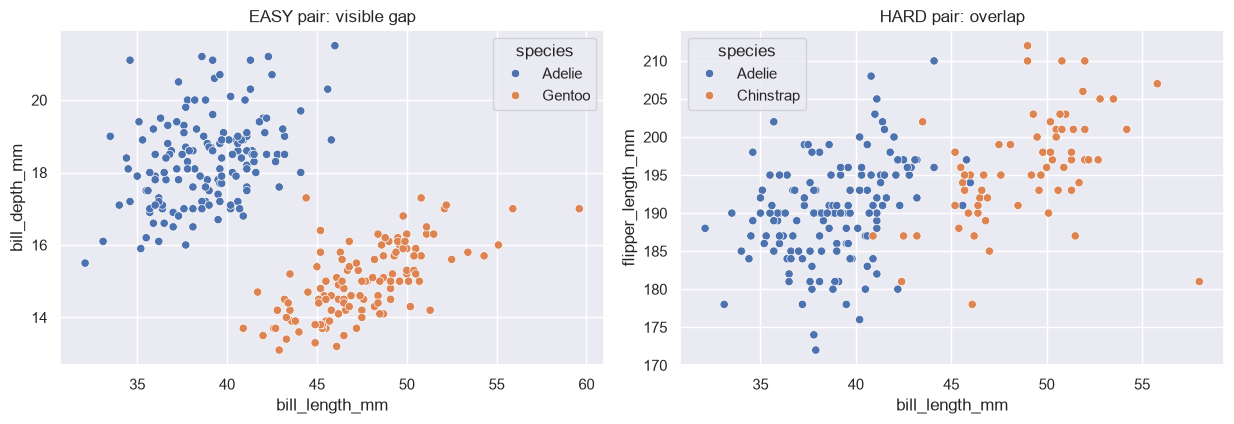

In [2]:
pen = get_data(
    "penguins.csv",
    "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv",
)
print("rows before cleaning:", len(pen))
pen = pen.dropna()                          # 11 rows carry some NaNs; drop & note
print("rows after dropna :", len(pen))

easy = pen[pen.species.isin(["Gentoo", "Adelie"])]          # separable duel
duel = pen[pen.species != "Gentoo"]                         # overlapping duel

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
sns.scatterplot(data=easy, x="bill_length_mm", y="bill_depth_mm",
                hue="species", ax=axes[0])
axes[0].set_title("EASY pair: visible gap")
sns.scatterplot(data=duel, x="bill_length_mm", y="flipper_length_mm",
                hue="species", ax=axes[1])
axes[1].set_title("HARD pair: overlap")
plt.tight_layout(); plt.show()

### 3. Exploratory Data Analysis (compact but real)


In [3]:
print(easy.groupby("species")[["bill_length_mm", "bill_depth_mm"]].mean().round(2))
print("\nmissing after dropna:", pen.isna().sum().sum())

         bill_length_mm  bill_depth_mm
species                               
Adelie            38.82          18.35
Gentoo            47.57          15.00

missing after dropna: 0


### 4. Data processing - features/target + stratified split (easy pair)


In [4]:
Xe = easy[["bill_length_mm", "bill_depth_mm"]]
ye = (easy.species == "Gentoo").astype(int)     # 1 = Gentoo

X_tr, X_te, y_tr, y_te = train_test_split(Xe, ye, test_size=.3,
                                          random_state=42, stratify=ye)

### 5. Model training - linear SVM and its margin street


easy-pair CV 0.995 | test acc 1.000
support vectors: 7 of 185


D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


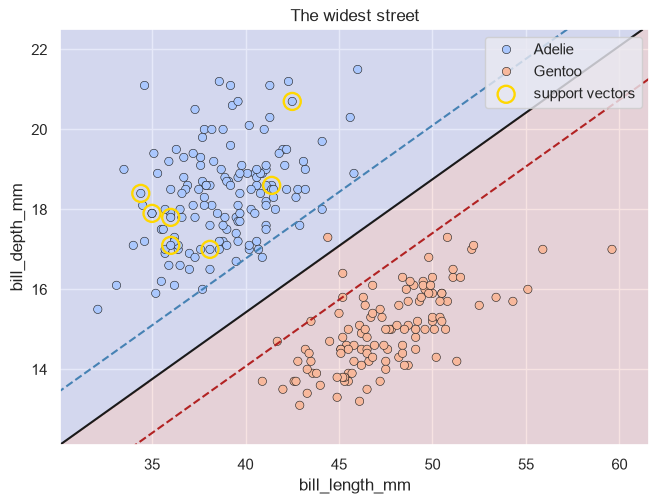

In [5]:
lin_svm = Pipeline([("sc", StandardScaler()),
                    ("svm", SVC(kernel="linear", C=1))]).fit(X_tr, y_tr)
cv = cross_val_score(lin_svm, X_tr, y_tr, cv=5).mean()
pred = lin_svm.predict(X_te)
print(f"easy-pair CV {cv:.3f} | test acc {accuracy_score(y_te, pred):.3f}")

svm_fitted = lin_svm.named_steps["svm"]
sv_idx = svm_fitted.support_
print(f"support vectors: {len(sv_idx)} of {len(X_tr)}")

sc = lin_svm.named_steps["sc"]
gx = np.linspace(Xe.bill_length_mm.min()-2, Xe.bill_length_mm.max()+2, 300)
gy = np.linspace(Xe.bill_depth_mm.min()-1, Xe.bill_depth_mm.max()+1, 300)
Gxx, Gyy = np.meshgrid(gx, gy)
zz = svm_fitted.decision_function(sc.transform(np.c_[Gxx.ravel(), Gyy.ravel()])) \
                 .reshape(Gxx.shape)

plt.figure(figsize=(7.6, 5.4))
plt.contourf(Gxx, Gyy, np.sign(zz), alpha=.14, cmap="coolwarm")
plt.contour(Gxx, Gyy, zz, levels=[-1, 0, 1],
            colors=["steelblue", "k", "firebrick"],
            linestyles=["--", "-", "--"])
sns.scatterplot(data=easy, x="bill_length_mm", y="bill_depth_mm",
                hue="species", palette="coolwarm", edgecolor="k", lw=.4)
plt.scatter(Xe.iloc[sv_idx]["bill_length_mm"],
            Xe.iloc[sv_idx]["bill_depth_mm"], s=150,
            facecolors="none", edgecolors="gold", lw=1.7,
            label="support vectors")
plt.legend(); plt.title("The widest street"); plt.show()

### 5b. Hard duel - RBF grid search


In [6]:
Xh = duel[["bill_length_mm", "flipper_length_mm"]]
yh = (duel.species == "Chinstrap").astype(int)
Xh_tr, Xh_te, yh_tr, yh_te = train_test_split(Xh, yh, test_size=.3,
                                              random_state=42, stratify=yh)

grid = GridSearchCV(Pipeline([("sc", StandardScaler()), ("svm", SVC())]),
                    {"svm__kernel": ["linear", "rbf"],
                     "svm__C": [0.5, 1, 10]},
                    cv=5)
grid.fit(Xh_tr, yh_tr)
ph = grid.predict(Xh_te)
print("hard-duel best:", grid.best_params_)
print(f"test accuracy: {accuracy_score(yh_te, ph):.3f}")
display(pd.DataFrame(confusion_matrix(yh_te, ph),
                     index=["true Adelie", "true Chinstrap"],
                     columns=["pred Adelie", "pred Chinstrap"]))

hard-duel best: {'svm__C': 10, 'svm__kernel': 'rbf'}
test accuracy: 0.969


,pred Adelie,pred Chinstrap
true Adelie,42,2
true Chinstrap,0,21


### 6. Findings

1. Easy pair ≈ perfect; only curb-riders define the street.
2. Hard pair tops ~85-92% - species genuinely overlap; no kernel fixes nature.
3. Measure separability FIRST, then pick kernel complexity.